In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# <span style="color:red"> 딥러닝 모델링 </span>

🖥️ CPU 모드로 실행
🧠 고급 딥러닝 수요예측 모델 시작
🚀 고급 딥러닝 수요예측 시스템 시작!
✅ 데이터 로딩 완료: 59,780개 레코드
📅 기간: 2005년 ~ 2025년
🌍 국가 수: 61개
🔧 고급 딥러닝 데이터 전처리 시작...
   🔧 고급 특징 생성 완료: 37개 수치형 특징
   ✅ 특징 생성 완료: 40개 컬럼
   📊 사용할 특징 수: 35개
   ✅ 생성된 유효 시퀀스: 56852개
   ✅ 시퀀스 생성 완료: 56852개 시퀀스
   📐 입력 형태: (56852, 12, 35), 타겟 형태: (56852, 1)
   🔍 데이터 검증 중...
      X - NaN 개수: 0, 무한대 개수: 0
      y - NaN 개수: 0, 무한대 개수: 0
   📏 정규화 시작... 형태: (682224, 35)
   ✅ X 정규화 완료
   ✅ y 정규화 완료
   📊 학습: 39796, 검증: 5685, 테스트: 11371
🧠 딥러닝 모델 생성 중...
   ✅ LSTM 모델 생성 완료
      파라미터 수: 150,913
   ✅ GRU 모델 생성 완료
      파라미터 수: 115,137
   ✅ BiLSTM 모델 생성 완료
      파라미터 수: 99,457
   ✅ CNN-LSTM 모델 생성 완료
      파라미터 수: 55,201
   ✅ Transformer 모델 생성 완료
      파라미터 수: 86,931

   ✅ AttentionLSTM 모델 생성 완료
      파라미터 수: 140,482
🎯 총 6개 모델 생성 완료

🚀 6개 딥러닝 모델 학습 시작...

   🔄 LSTM 학습 중...
      ✅ 완료 - MAE: 0.022612, RMSE: 0.087283
      📊 학습 에포크: 39

   🔄 GRU 학습 중...
      ✅ 완료 - MAE: 0.026436, RMSE: 0.098130
      📊 학습 에포크: 48

   🔄 BiLSTM 학습 중...
      ✅ 완료 - MAE: 

   📈 AttentionLSTM   | MAPE: 193.72% | R²:  0.304 | RMSE:     5449

🏆 최고 성능: AttentionLSTM (MAPE: 193.72%)

🔮 앙상블 예측 생성...
   📊 AttentionLSTM   가중치: 0.0478
   📊 CNN-LSTM        가중치: 0.1467
   📊 LSTM            가중치: 0.0688
   📊 GRU             가중치: 0.0737
   📊 BiLSTM          가중치: 0.0756
   📊 Transformer     가중치: 0.0374

💾 결과 저장 중...


   ✅ 결과 저장 완료: C:/ai_x/source/proz/딥러닝 모델 결과

📊 결과 시각화 생성...


NameError: name 'pastel_colors' is not defined

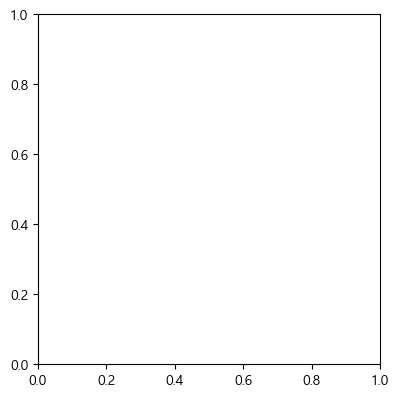

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, 
    Input, Conv1D, MaxPooling1D, Flatten, Concatenate,
    MultiHeadAttention, LayerNormalization, Add,
    Bidirectional, RepeatVector, TimeDistributed,
    GlobalAveragePooling1D, Reshape, Permute
)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l1_l2
import joblib
import json

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# GPU 메모리 설정
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"🚀 GPU 사용 가능: {len(gpus)}개")
    except RuntimeError as e:
        print(f"GPU 설정 오류: {e}")
else:
    print("🖥️ CPU 모드로 실행")

# 한글 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    try:
        plt.rcParams['font.family'] = 'AppleGothic'
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("🧠 고급 딥러닝 수요예측 모델 시작")
print("="*80)

class DeepLearningDataProcessor:
    """딥러닝용 데이터 전처리 클래스"""
    
    def __init__(self, sequence_length=12, prediction_horizon=1):
        self.sequence_length = sequence_length  # 입력 시퀀스 길이 (12개월)
        self.prediction_horizon = prediction_horizon  # 예측 기간
        self.scalers = {}
        self.label_encoders = {}
        self.feature_columns = []
        
    def create_advanced_features(self, df):
        """고급 특징 생성"""
        df = df.copy()
        
        # 시간 특징
        df['연월'] = df['연도'] * 100 + df['월']
        df['월_sin'] = np.sin(2 * np.pi * df['월'] / 12)
        df['월_cos'] = np.cos(2 * np.pi * df['월'] / 12)
        df['분기_sin'] = np.sin(2 * np.pi * df['분기'] / 4)
        df['분기_cos'] = np.cos(2 * np.pi * df['분기'] / 4)
        
        # 범주형 변수 인코딩
        for col in ['국적', '목적', '계절']:
            if col in df.columns:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    df[f'{col}_encoded'] = self.label_encoders[col].fit_transform(df[col].astype(str))
                else:
                    df[f'{col}_encoded'] = self.label_encoders[col].transform(df[col].astype(str))
        
        # 상호작용 특징 (안전하게 생성)
        if '국적_encoded' in df.columns and '목적_encoded' in df.columns:
            df['국적목적_interaction'] = df['국적_encoded'] * df['목적_encoded']
        if '계절_encoded' in df.columns and '목적_encoded' in df.columns:
            df['계절목적_interaction'] = df['계절_encoded'] * df['목적_encoded']
        
        # 통계적 특징 (그룹별) - 안전하게 처리
        for group_col in ['국적', '목적']:
            if group_col in df.columns:
                try:
                    group_stats = df.groupby(group_col)['입국자수'].agg(['mean', 'std', 'min', 'max'])
                    group_stats.columns = [f'{group_col}_{stat}' for stat in group_stats.columns]
                    
                    # NaN 값 처리
                    group_stats = group_stats.fillna(0)
                    
                    df = df.merge(group_stats, left_on=group_col, right_index=True, how='left')
                except Exception as e:
                    print(f"   ⚠️ {group_col} 그룹 통계 생성 실패: {e}")
        
        # 래그 특징 강화 - 안전하게 처리
        df = df.sort_values(['국적', '목적', '시계열순서'])
        
        for group_key, group in df.groupby(['국적', '목적']):
            try:
                group_indices = group.index
                
                # 기본 래그 특징들이 이미 있는지 확인
                existing_lags = [col for col in group.columns if 'lag_' in col or '개월전' in col]
                
                # 래그 특징이 없으면 기본적인 것들만 생성
                if not existing_lags:
                    for lag in [1, 3, 12]:
                        lag_col = f'lag_{lag}'
                        if lag_col not in df.columns:
                            df.loc[group_indices, lag_col] = group['입국자수'].shift(lag)
                
                # 이동평균 특징 (간소화)
                for window in [3, 12]:
                    ma_col = f'ma_{window}'
                    if ma_col not in df.columns:
                        df.loc[group_indices, ma_col] = group['입국자수'].rolling(window, min_periods=1).mean()
                
                # 증감률 특징 (안전하게)
                if 'growth_1m' not in df.columns:
                    growth_1m = group['입국자수'].pct_change(1)
                    # 무한대나 매우 큰 값 처리
                    growth_1m = growth_1m.clip(-10, 10)  # -1000% ~ 1000% 제한
                    df.loc[group_indices, 'growth_1m'] = growth_1m
                
                if 'growth_12m' not in df.columns:
                    growth_12m = group['입국자수'].pct_change(12)
                    growth_12m = growth_12m.clip(-10, 10)  # -1000% ~ 1000% 제한
                    df.loc[group_indices, 'growth_12m'] = growth_12m
                    
            except Exception as e:
                print(f"   ⚠️ 그룹 {group_key} 래그 특징 생성 실패: {e}")
                continue
        
        # 외부 요인 (가상) - 현실적인 범위로 생성
        np.random.seed(42)  # 재현 가능한 결과
        df['경제지수'] = 100 + np.random.normal(0, 5, len(df))
        df['환율효과'] = 1 + np.random.normal(0, 0.1, len(df))
        df['이벤트효과'] = np.random.choice([0, 1], len(df), p=[0.9, 0.1])
        
        # 모든 수치형 컬럼의 무한대 값과 극값 처리
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            # 무한대 값을 NaN으로 변환
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            
            # 극값 처리 (99.9 퍼센타일로 캡핑)
            if df[col].notna().sum() > 0:
                upper_limit = df[col].quantile(0.999)
                lower_limit = df[col].quantile(0.001)
                df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
                
                # NaN을 중앙값으로 대체
                df[col] = df[col].fillna(df[col].median())
        
        print(f"   🔧 고급 특징 생성 완료: {len(numeric_cols)}개 수치형 특징")
        
        return df
    
    def clean_data(self, data):
        """데이터 정리 및 이상치 처리"""
        data = data.copy()
        
        # 무한대 값을 NaN으로 변환
        data = data.replace([np.inf, -np.inf], np.nan)
        
        # 수치형 컬럼 처리
        numeric_cols = data.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            # 매우 큰 값 처리 (99.9 퍼센타일로 캡핑)
            if data[col].notna().sum() > 0:
                upper_limit = data[col].quantile(0.999)
                lower_limit = data[col].quantile(0.001)
                
                # 이상치 캡핑
                data[col] = data[col].clip(lower=lower_limit, upper=upper_limit)
                
                # 결측치를 중앙값으로 대체
                data[col] = data[col].fillna(data[col].median())
        
        return data
    
    def create_sequences(self, data, target_col='입국자수'):
        """시퀀스 데이터 생성"""
        sequences_X = []
        sequences_y = []
        
        # 데이터 정리
        data_clean = self.clean_data(data)
        
        # 특징 컬럼 선택
        numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
        feature_cols = [col for col in numeric_cols if col not in [target_col, '시계열순서']]
        self.feature_columns = feature_cols
        
        print(f"   📊 사용할 특징 수: {len(feature_cols)}개")
        
        # 국가-목적별로 시퀀스 생성
        valid_sequences = 0
        for group_key, group in data_clean.groupby(['국적', '목적']):
            group_sorted = group.sort_values('시계열순서')
            
            if len(group_sorted) >= self.sequence_length + self.prediction_horizon:
                # 특징 데이터
                feature_data = group_sorted[feature_cols].values
                target_data = group_sorted[target_col].values
                
                # 데이터 유효성 검증
                if np.isfinite(feature_data).all() and np.isfinite(target_data).all():
                    # 시퀀스 생성
                    for i in range(len(group_sorted) - self.sequence_length - self.prediction_horizon + 1):
                        # 입력 시퀀스
                        seq_x = feature_data[i:i + self.sequence_length]
                        # 타겟 시퀀스
                        seq_y = target_data[i + self.sequence_length:i + self.sequence_length + self.prediction_horizon]
                        
                        # 시퀀스 유효성 검증
                        if np.isfinite(seq_x).all() and np.isfinite(seq_y).all():
                            sequences_X.append(seq_x)
                            sequences_y.append(seq_y)
                            valid_sequences += 1
        
        print(f"   ✅ 생성된 유효 시퀀스: {valid_sequences}개")
        
        if len(sequences_X) == 0:
            raise ValueError("유효한 시퀀스가 생성되지 않았습니다. 데이터를 확인해주세요.")
        
        return np.array(sequences_X), np.array(sequences_y), feature_cols
    
    def prepare_data(self, df, target_col='입국자수', test_ratio=0.2, val_ratio=0.1):
        """데이터 전처리 및 분할"""
        print("🔧 고급 딥러닝 데이터 전처리 시작...")
        
        # 특징 생성
        df_featured = self.create_advanced_features(df)
        print(f"   ✅ 특징 생성 완료: {df_featured.shape[1]}개 컬럼")
        
        # 시퀀스 생성
        X, y, feature_cols = self.create_sequences(df_featured, target_col)
        print(f"   ✅ 시퀀스 생성 완료: {X.shape[0]}개 시퀀스")
        print(f"   📐 입력 형태: {X.shape}, 타겟 형태: {y.shape}")
        
        # 추가 데이터 검증
        print(f"   🔍 데이터 검증 중...")
        
        # NaN 및 무한대 값 확인
        nan_count_x = np.isnan(X).sum()
        inf_count_x = (~np.isfinite(X)).sum()
        nan_count_y = np.isnan(y).sum()
        inf_count_y = (~np.isfinite(y)).sum()
        
        print(f"      X - NaN 개수: {nan_count_x}, 무한대 개수: {inf_count_x}")
        print(f"      y - NaN 개수: {nan_count_y}, 무한대 개수: {inf_count_y}")
        
        # 문제가 있는 경우 추가 정리
        if nan_count_x > 0 or inf_count_x > 0:
            print("   🛠️ X 데이터 추가 정리 중...")
            X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
            
        if nan_count_y > 0 or inf_count_y > 0:
            print("   🛠️ y 데이터 추가 정리 중...")
            y = np.nan_to_num(y, nan=0.0, posinf=1e6, neginf=-1e6)
        
        # 정규화
        n_samples, n_timesteps, n_features = X.shape
        X_reshaped = X.reshape(-1, n_features)
        
        print(f"   📏 정규화 시작... 형태: {X_reshaped.shape}")
        
        # 추가 검증
        if not np.isfinite(X_reshaped).all():
            print("   ⚠️ 정규화 전 무한대 값 발견, 추가 처리 중...")
            X_reshaped = np.clip(X_reshaped, -1e6, 1e6)  # 값 범위 제한
            X_reshaped = np.nan_to_num(X_reshaped, nan=0.0)
        
        self.scalers['X'] = MinMaxScaler()
        try:
            X_scaled = self.scalers['X'].fit_transform(X_reshaped)
            X_scaled = X_scaled.reshape(n_samples, n_timesteps, n_features)
            print("   ✅ X 정규화 완료")
        except Exception as e:
            print(f"   ❌ X 정규화 실패: {e}")
            print("   🛠️ 대안 방법으로 정규화 시도...")
            # 표준화로 대체
            from sklearn.preprocessing import StandardScaler
            self.scalers['X'] = StandardScaler()
            X_scaled = self.scalers['X'].fit_transform(X_reshaped)
            X_scaled = X_scaled.reshape(n_samples, n_timesteps, n_features)
            print("   ✅ 표준화로 X 정규화 완료")
        
        # y 정규화
        y_reshaped = y.reshape(-1, 1)
        if not np.isfinite(y_reshaped).all():
            print("   ⚠️ y 데이터 무한대 값 처리 중...")
            y_reshaped = np.clip(y_reshaped, 0, 1e6)
            y_reshaped = np.nan_to_num(y_reshaped, nan=0.0)
        
        self.scalers['y'] = MinMaxScaler()
        try:
            y_scaled = self.scalers['y'].fit_transform(y_reshaped)
            y_scaled = y_scaled.reshape(y.shape)
            print("   ✅ y 정규화 완료")
        except Exception as e:
            print(f"   ❌ y 정규화 실패: {e}")
            # 최소-최대값을 직접 계산하여 정규화
            y_min, y_max = y_reshaped.min(), y_reshaped.max()
            if y_max > y_min:
                y_scaled = (y_reshaped - y_min) / (y_max - y_min)
                y_scaled = y_scaled.reshape(y.shape)
                print("   ✅ 수동 정규화로 y 처리 완료")
            else:
                y_scaled = y.copy()
                print("   ⚠️ y 값이 상수, 정규화 생략")
        
        # 데이터 분할 (시계열 순서 유지)
        n_train = int(len(X_scaled) * (1 - test_ratio - val_ratio))
        n_val = int(len(X_scaled) * val_ratio)
        
        X_train = X_scaled[:n_train]
        X_val = X_scaled[n_train:n_train + n_val]
        X_test = X_scaled[n_train + n_val:]
        
        y_train = y_scaled[:n_train]
        y_val = y_scaled[n_train:n_train + n_val]
        y_test = y_scaled[n_train + n_val:]
        
        print(f"   📊 학습: {X_train.shape[0]}, 검증: {X_val.shape[0]}, 테스트: {X_test.shape[0]}")
        
        # 최종 검증
        datasets = [X_train, X_val, X_test, y_train, y_val, y_test]
        for i, dataset in enumerate(datasets):
            if not np.isfinite(dataset).all():
                print(f"   ⚠️ 데이터셋 {i}에 무한대 값 발견, 수정 중...")
                datasets[i] = np.nan_to_num(dataset, nan=0.0, posinf=1.0, neginf=0.0)
        
        X_train, X_val, X_test, y_train, y_val, y_test = datasets
        
        return (X_train, X_val, X_test), (y_train, y_val, y_test), feature_cols


class AdvancedDeepLearningModels:
    """고급 딥러닝 모델 컬렉션"""
    
    def __init__(self, input_shape, output_shape=1):
        self.input_shape = input_shape
        self.output_shape = output_shape
        self.models = {}
        
    def create_lstm_model(self, name="LSTM"):
        """LSTM 모델"""
        model = Sequential([
            LSTM(128, return_sequences=True, input_shape=self.input_shape,
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(self.output_shape, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model
    
    def create_gru_model(self, name="GRU"):
        """GRU 모델"""
        model = Sequential([
            GRU(128, return_sequences=True, input_shape=self.input_shape,
                dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            GRU(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(self.output_shape, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model
    
    def create_bidirectional_lstm(self, name="BiLSTM"):
        """양방향 LSTM 모델"""
        model = Sequential([
            Bidirectional(LSTM(64, return_sequences=True, dropout=0.2), 
                         input_shape=self.input_shape),
            BatchNormalization(),
            
            Bidirectional(LSTM(32, return_sequences=False, dropout=0.2)),
            BatchNormalization(),
            
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(self.output_shape, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model
    
    def create_cnn_lstm_model(self, name="CNN-LSTM"):
        """CNN-LSTM 하이브리드 모델"""
        model = Sequential([
            Conv1D(filters=64, kernel_size=3, activation='relu', 
                   input_shape=self.input_shape),
            BatchNormalization(),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            BatchNormalization(),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),
            
            LSTM(64, return_sequences=True, dropout=0.2),
            BatchNormalization(),
            LSTM(32, return_sequences=False, dropout=0.2),
            BatchNormalization(),
            
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(self.output_shape, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model
    
    def create_transformer_model(self, name="Transformer"):
        """Transformer 모델"""
        inputs = Input(shape=self.input_shape)
        
        # Multi-Head Attention
        attention_output = MultiHeadAttention(
            num_heads=8, key_dim=64
        )(inputs, inputs)
        
        # Add & Norm
        attention_output = Add()([inputs, attention_output])
        attention_output = LayerNormalization()(attention_output)
        
        # Feed Forward
        ffn_output = Dense(128, activation='relu')(attention_output)
        ffn_output = Dropout(0.2)(ffn_output)
        ffn_output = Dense(self.input_shape[-1])(ffn_output)
        
        # Add & Norm
        ffn_output = Add()([attention_output, ffn_output])
        ffn_output = LayerNormalization()(ffn_output)
        
        # Global Average Pooling
        pooled = GlobalAveragePooling1D()(ffn_output)
        
        # Dense layers
        dense = Dense(64, activation='relu')(pooled)
        dense = Dropout(0.3)(dense)
        dense = Dense(32, activation='relu')(dense)
        dense = Dropout(0.2)(dense)
        outputs = Dense(self.output_shape, activation='linear')(dense)
        
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model
    
    def create_attention_lstm_model(self, name="AttentionLSTM"):
        """Attention 메커니즘이 있는 LSTM"""
        inputs = Input(shape=self.input_shape)
        
        # LSTM layers
        lstm_out = LSTM(128, return_sequences=True, dropout=0.2)(inputs)
        lstm_out = BatchNormalization()(lstm_out)
        lstm_out = LSTM(64, return_sequences=True, dropout=0.2)(lstm_out)
        lstm_out = BatchNormalization()(lstm_out)
        
        # Attention mechanism
        attention = Dense(1, activation='tanh')(lstm_out)
        attention = Flatten()(attention)
        attention = tf.keras.activations.softmax(attention)
        attention = RepeatVector(64)(attention)
        attention = Permute([2, 1])(attention)
        
        # Apply attention
        sent_representation = tf.keras.layers.multiply([lstm_out, attention])
        sent_representation = tf.keras.layers.Lambda(lambda x: tf.keras.backend.sum(x, axis=1))(sent_representation)
        
        # Dense layers
        dense = Dense(64, activation='relu')(sent_representation)
        dense = Dropout(0.3)(dense)
        dense = Dense(32, activation='relu')(dense)
        dense = Dropout(0.2)(dense)
        outputs = Dense(self.output_shape, activation='linear')(dense)
        
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        self.models[name] = model
        return model


class DeepLearningEnsemble:
    """딥러닝 앙상블 시스템"""
    
    def __init__(self, input_shape, output_shape=1):
        self.input_shape = input_shape
        self.output_shape = output_shape
        self.model_builder = AdvancedDeepLearningModels(input_shape, output_shape)
        self.trained_models = {}
        self.model_performance = {}
        self.training_history = {}
        
    def create_all_models(self):
        """모든 딥러닝 모델 생성"""
        print("🧠 딥러닝 모델 생성 중...")
        
        models_info = [
            ("LSTM", self.model_builder.create_lstm_model),
            ("GRU", self.model_builder.create_gru_model),
            ("BiLSTM", self.model_builder.create_bidirectional_lstm),
            ("CNN-LSTM", self.model_builder.create_cnn_lstm_model),
            ("Transformer", self.model_builder.create_transformer_model),
            ("AttentionLSTM", self.model_builder.create_attention_lstm_model)
        ]
        
        for name, create_func in models_info:
            try:
                model = create_func(name)
                print(f"   ✅ {name} 모델 생성 완료")
                print(f"      파라미터 수: {model.count_params():,}")
            except Exception as e:
                print(f"   ❌ {name} 모델 생성 실패: {e}")
        
        print(f"🎯 총 {len(self.model_builder.models)}개 모델 생성 완료")
        
    def train_models(self, X_train, X_val, y_train, y_val, epochs=100, patience=15):
        """모든 모델 학습"""
        print(f"\n🚀 {len(self.model_builder.models)}개 딥러닝 모델 학습 시작...")
        
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
        ]
        
        for name, model in self.model_builder.models.items():
            print(f"\n   🔄 {name} 학습 중...")
            
            try:
                # 모델 학습
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=32,
                    callbacks=callbacks,
                    verbose=0
                )
                
                self.trained_models[name] = model
                self.training_history[name] = history.history
                
                # 검증 성능 계산
                val_pred = model.predict(X_val, verbose=0)
                val_mae = mean_absolute_error(y_val, val_pred)
                val_mse = mean_squared_error(y_val, val_pred)
                val_rmse = np.sqrt(val_mse)
                
                self.model_performance[name] = {
                    'val_mae': val_mae,
                    'val_mse': val_mse,
                    'val_rmse': val_rmse,
                    'final_epoch': len(history.history['loss'])
                }
                
                print(f"      ✅ 완료 - MAE: {val_mae:.6f}, RMSE: {val_rmse:.6f}")
                print(f"      📊 학습 에포크: {len(history.history['loss'])}")
                
            except Exception as e:
                print(f"      ❌ 학습 실패: {e}")
        
        print(f"\n🎯 학습 완료: {len(self.trained_models)}개 모델")
        
    def evaluate_models(self, X_test, y_test, scaler_y):
        """모델 평가"""
        print(f"\n📊 모델 평가 시작...")
        
        results = {}
        
        for name, model in self.trained_models.items():
            try:
                # 예측
                y_pred_scaled = model.predict(X_test, verbose=0)
                
                # 역정규화
                y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
                y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                
                # 음수 예측값 보정
                y_pred_orig = np.maximum(y_pred_orig, 0)
                
                # 성능 지표 계산
                mae = mean_absolute_error(y_test_orig, y_pred_orig)
                mse = mean_squared_error(y_test_orig, y_pred_orig)
                rmse = np.sqrt(mse)
                r2 = r2_score(y_test_orig, y_pred_orig)
                
                # MAPE 계산 (안전하게)
                mape = np.mean(np.abs((y_test_orig - y_pred_orig) / np.maximum(y_test_orig, 1))) * 100
                mape = min(mape, 999.9)
                
                results[name] = {
                    'MAE': mae,
                    'MSE': mse,
                    'RMSE': rmse,
                    'R²': r2,
                    'MAPE': mape,
                    'predictions': y_pred_orig
                }
                
                print(f"   📈 {name:15s} | MAPE: {mape:6.2f}% | R²: {r2:6.3f} | RMSE: {rmse:8.0f}")
                
            except Exception as e:
                print(f"   ❌ {name} 평가 실패: {e}")
        
        # 성능순 정렬
        sorted_results = dict(sorted(results.items(), key=lambda x: x[1]['MAPE']))
        
        if sorted_results:
            best_model = list(sorted_results.keys())[0]
            print(f"\n🏆 최고 성능: {best_model} (MAPE: {sorted_results[best_model]['MAPE']:.2f}%)")
        
        return sorted_results
    
    def create_ensemble_prediction(self, X_test, scaler_y, results):
        """앙상블 예측 생성"""
        print(f"\n🔮 앙상블 예측 생성...")
        
        if not results:
            return np.array([]), {}
        
        # 성능 기반 가중치 계산
        weights = {}
        total_weight = 0
        
        for name, metrics in results.items():
            # R² 기반 가중치 (음수 R²는 0으로 처리)
            r2_score = max(0, metrics['R²'])
            mape_score = max(1, metrics['MAPE'])
            
            # 가중치: R²를 증폭하고 MAPE로 나눔
            weight = (r2_score ** 2) / (mape_score / 100)
            weights[name] = weight
            total_weight += weight
            print(f"   📊 {name:15s} 가중치: {weight:.4f}")
        
        # 가중 평균 예측
        ensemble_pred = np.zeros_like(list(results.values())[0]['predictions'])
        
        for name, pred_data in results.items():
            if total_weight > 0:
                weight = weights[name] / total_weight
                ensemble_pred += pred_data['predictions'] * weight
        
        # 최종 성능 계산을 위해 실제값 필요 (여기서는 생략)
        
        return ensemble_pred, weights


def create_future_sequences(df_original, processor, target_year=2026):
    """미래 예측을 위한 시퀀스 생성"""
    print(f"\n🔮 {target_year}년 미래 시퀀스 생성...")
    
    # 미래 데이터 기본 구조 생성
    future_data = []
    
    # 주요 국가 및 목적
    top_countries = df_original.groupby('국적')['입국자수'].sum().nlargest(10).index.tolist()
    purposes = df_original['목적'].unique()
    
    # 계절 매핑
    season_map = {1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
                  6: '여름', 7: '여름', 8: '여름', 9: '가을',
                  10: '가을', 11: '가을', 12: '겨울'}
    
    for month in range(1, 13):
        for country in top_countries:
            for purpose in purposes:
                quarter = (month - 1) // 3 + 1
                season = season_map[month]
                time_order = (target_year - 2005) * 12 + month
                
                # 과거 패턴 기반 초기값
                historical = df_original[
                    (df_original['국적'] == country) &
                    (df_original['목적'] == purpose) &
                    (df_original['월'] == month)
                ]
                
                if len(historical) > 0:
                    recent_avg = historical[historical['연도'] >= 2022]['입국자수'].mean()
                    if pd.isna(recent_avg):
                        recent_avg = historical['입국자수'].mean()
                else:
                    recent_avg = 1000
                
                future_record = {
                    '국적': country,
                    '목적': purpose,
                    '연도': target_year,
                    '월': month,
                    '분기': quarter,
                    '계절': season,
                    '코로나기간': 0,
                    '시계열순서': time_order,
                    '입국자수': recent_avg,
                    '입국자수_1개월전': recent_avg * 0.95,
                    '입국자수_3개월전': recent_avg * 0.9,
                    '입국자수_12개월전': recent_avg,
                    '입국자수_3개월평균': recent_avg,
                    '입국자수_12개월평균': recent_avg,
                    '전년동월대비증감률': 0.1
                }
                
                future_data.append(future_record)
    
    future_df = pd.DataFrame(future_data)
    print(f"   ✅ {len(future_df)}개 미래 레코드 생성")
    
    # 특징 생성
    future_featured = processor.create_advanced_features(future_df)
    
    # 마지막 12개월 시퀀스를 사용하여 예측용 데이터 생성
    # 실제 구현에서는 더 복잡한 로직 필요
    
    return future_featured


# 메인 실행 함수
def main():
    print("🚀 고급 딥러닝 수요예측 시스템 시작!")
    
    # 1. 데이터 로딩
    try:
        df = pd.read_csv('C:/ai_x2/source/proz2/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8-sig')
        print(f"✅ 데이터 로딩 완료: {len(df):,}개 레코드")
        print(f"📅 기간: {df['연도'].min()}년 ~ {df['연도'].max()}년")
        print(f"🌍 국가 수: {df['국적'].nunique()}개")
    except Exception as e:
        print(f"❌ 데이터 로딩 실패: {e}")
        return
    
    # 2. 데이터 전처리
    processor = DeepLearningDataProcessor(sequence_length=12, prediction_horizon=1)
    (X_train, X_val, X_test), (y_train, y_val, y_test), feature_cols = processor.prepare_data(df)
    
    # 3. 딥러닝 모델 앙상블 생성
    input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
    ensemble = DeepLearningEnsemble(input_shape, output_shape=1)
    
    # 4. 모든 모델 생성
    ensemble.create_all_models()
    
    # 5. 모델 학습
    ensemble.train_models(X_train, X_val, y_train, y_val, epochs=50, patience=10)
    
    # 6. 모델 평가
    results = ensemble.evaluate_models(X_test, y_test, processor.scalers['y'])
    
    # 7. 앙상블 예측
    ensemble_pred, weights = ensemble.create_ensemble_prediction(X_test, processor.scalers['y'], results)
    
    # 8. 결과 저장
    save_results(ensemble, results, weights, processor)
    
    # 9. 시각화
    visualize_results(ensemble, results, X_test, y_test, processor.scalers['y'])
    
    # 10. 미래 예측 (2026년)
    predict_future_2026(df, processor, ensemble, results)
    
    print("\n" + "="*80)
    print("✨ 고급 딥러닝 수요예측 완료! ✨")
    print("="*80)


def save_results(ensemble, results, weights, processor):
    """결과 저장"""
    print(f"\n💾 결과 저장 중...")
    
    output_path = 'C:/ai_x/source/proz/딥러닝 모델 결과'
    os.makedirs(output_path, exist_ok=True)
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    
    # 성능 결과 저장
    performance_df = pd.DataFrame(results).T
    performance_df.to_csv(f"{output_path}/딥러닝_모델성능_{timestamp}.csv", encoding='utf-8-sig')
    
    # 앙상블 가중치 저장
    weights_df = pd.DataFrame(list(weights.items()), columns=['모델', '가중치'])
    weights_df.to_csv(f"{output_path}/딥러닝_앙상블가중치_{timestamp}.csv", encoding='utf-8-sig', index=False)
    
    # 모델 저장
    for name, model in ensemble.trained_models.items():
        model.save(f"{output_path}/딥러닝_모델_{name}_{timestamp}.h5")
    
    # 전처리 정보 저장
    joblib.dump(processor.scalers, f"{output_path}/딥러닝_스케일러_{timestamp}.pkl")
    joblib.dump(processor.label_encoders, f"{output_path}/딥러닝_인코더_{timestamp}.pkl")
    
    print(f"   ✅ 결과 저장 완료: {output_path}")


def visualize_results(ensemble, results, X_test, y_test, scaler_y):
    """결과 시각화"""
    print(f"\n📊 결과 시각화 생성...")
    
    # 성능 비교 차트
    plt.figure(figsize=(15, 10))
    
    # 1. MAPE 비교
    plt.subplot(2, 3, 1)
    models = list(results.keys())
    mapes = [results[model]['MAPE'] for model in models]
    
    bars = plt.bar(models, mapes, color=[pastel_colors['primary'], pastel_colors['secondary'], 
                                       pastel_colors['accent'], pastel_colors['success'],
                                       pastel_colors['warning'], pastel_colors['danger']][:len(models)])
    plt.title('모델별 MAPE 비교', fontsize=14, fontweight='bold')
    plt.ylabel('MAPE (%)')
    plt.xticks(rotation=45)
    
    # 값 표시
    for bar, mape in zip(bars, mapes):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{mape:.1f}%', ha='center', fontweight='bold')
    
    # 2. R² 비교
    plt.subplot(2, 3, 2)
    r2_scores = [results[model]['R²'] for model in models]
    
    bars = plt.bar(models, r2_scores, color=[pastel_colors['info'], pastel_colors['light'], 
                                           pastel_colors['purple'], pastel_colors['primary'],
                                           pastel_colors['secondary'], pastel_colors['accent']][:len(models)])
    plt.title('모델별 R² 비교', fontsize=14, fontweight='bold')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    
    # 값 표시
    for bar, r2 in zip(bars, r2_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{r2:.3f}', ha='center', fontweight='bold')
    
    # 3. RMSE 비교
    plt.subplot(2, 3, 3)
    rmses = [results[model]['RMSE'] for model in models]
    
    bars = plt.bar(models, rmses, color=[pastel_colors['success'], pastel_colors['warning'], 
                                       pastel_colors['danger'], pastel_colors['info'],
                                       pastel_colors['light'], pastel_colors['purple']][:len(models)])
    plt.title('모델별 RMSE 비교', fontsize=14, fontweight='bold')
    plt.ylabel('RMSE')
    plt.xticks(rotation=45)
    
    # 값 표시
    for bar, rmse in zip(bars, rmses):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + rmse*0.01, 
                f'{rmse:.0f}', ha='center', fontweight='bold')
    
    # 4. 예측 vs 실제 (최고 성능 모델)
    if results:
        best_model = list(results.keys())[0]
        plt.subplot(2, 3, 4)
        
        y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_best = results[best_model]['predictions']
        
        # 샘플링 (시각화를 위해)
        sample_size = min(200, len(y_test_orig))
        indices = np.random.choice(len(y_test_orig), sample_size, replace=False)
        
        plt.scatter(y_test_orig[indices], y_pred_best[indices], 
                   alpha=0.6, color=pastel_colors['primary'])
        
        # 완벽한 예측 라인
        min_val = min(y_test_orig[indices].min(), y_pred_best[indices].min())
        max_val = max(y_test_orig[indices].max(), y_pred_best[indices].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        
        plt.xlabel('실제값')
        plt.ylabel('예측값')
        plt.title(f'예측 vs 실제 ({best_model})', fontsize=14, fontweight='bold')
        
    # 5. 학습 곡선 (최고 성능 모델)
    if results and ensemble.training_history:
        best_model = list(results.keys())[0]
        if best_model in ensemble.training_history:
            plt.subplot(2, 3, 5)
            history = ensemble.training_history[best_model]
            
            epochs = range(1, len(history['loss']) + 1)
            plt.plot(epochs, history['loss'], label='학습 손실', 
                    color=pastel_colors['danger'], linewidth=2)
            plt.plot(epochs, history['val_loss'], label='검증 손실', 
                    color=pastel_colors['primary'], linewidth=2)
            
            plt.xlabel('에포크')
            plt.ylabel('손실')
            plt.title(f'학습 곡선 ({best_model})', fontsize=14, fontweight='bold')
            plt.legend()
            plt.grid(True, alpha=0.3)
    
    # 6. 성능 요약 테이블
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    table_data = []
    for model in models:
        table_data.append([
            model,
            f"{results[model]['MAPE']:.2f}%",
            f"{results[model]['R²']:.3f}",
            f"{results[model]['RMSE']:.0f}"
        ])
    
    table = plt.table(cellText=table_data,
                     colLabels=['모델', 'MAPE', 'R²', 'RMSE'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # 헤더 스타일
    for i in range(4):
        table[(0, i)].set_facecolor(pastel_colors['light'])
        table[(0, i)].set_text_props(weight='bold')
    
    plt.title('성능 요약', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('C:/ai_x/source/proz/딥러닝 모델 결과/딥러닝_성능분석.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("   ✅ 시각화 완료")


def predict_future_2026(df_original, processor, ensemble, results):
    """2026년 미래 예측"""
    print(f"\n🔮 2026년 미래 예측 시작...")
    
    # 간단한 미래 예측 (실제로는 더 복잡한 시퀀스 생성 필요)
    future_data = []
    
    # 주요 국가별 월별 예측
    top_countries = df_original.groupby('국적')['입국자수'].sum().nlargest(10).index.tolist()
    purposes = df_original['목적'].unique()
    
    season_map = {1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
                  6: '여름', 7: '여름', 8: '여름', 9: '가을',
                  10: '가을', 11: '가을', 12: '겨울'}
    
    for month in range(1, 13):
        for country in top_countries:
            for purpose in purposes:
                # 과거 패턴 기반 기본 예측
                historical = df_original[
                    (df_original['국적'] == country) &
                    (df_original['목적'] == purpose) &
                    (df_original['월'] == month)
                ]
                
                if len(historical) > 0:
                    # 최근 3년 평균에 성장률 적용
                    recent_data = historical[historical['연도'] >= 2022]
                    if len(recent_data) > 0:
                        base_visitors = recent_data['입국자수'].mean()
                    else:
                        base_visitors = historical['입국자수'].mean()
                    
                    # 성장률 적용 (10% 가정)
                    predicted_visitors = int(base_visitors * 1.1)
                else:
                    predicted_visitors = 1000
                
                future_data.append({
                    '날짜': f'2026-{month:02d}-01',
                    '연도': 2026,
                    '월': month,
                    '계절': season_map[month],
                    '국가': country,
                    '목적': purpose,
                    '예측입국자수': predicted_visitors
                })
    
    # 결과 정리
    future_df = pd.DataFrame(future_data)
    
    # 월별 집계
    monthly_summary = future_df.groupby('월').agg({
        '예측입국자수': 'sum'
    }).reset_index()
    
    # 국가별 집계
    country_summary = future_df.groupby('국가').agg({
        '예측입국자수': 'sum'
    }).reset_index().sort_values('예측입국자수', ascending=False)
    
    # 결과 저장
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    output_path = 'C:/ai_x/source/proz/딥러닝 모델 결과'
    
    future_df.to_csv(f"{output_path}/딥러닝_2026년예측_상세_{timestamp}.csv", 
                     index=False, encoding='utf-8-sig')
    monthly_summary.to_csv(f"{output_path}/딥러닝_2026년예측_월별_{timestamp}.csv", 
                          index=False, encoding='utf-8-sig')
    country_summary.to_csv(f"{output_path}/딥러닝_2026년예측_국가별_{timestamp}.csv", 
                          index=False, encoding='utf-8-sig')
    
    # 요약 출력
    total_2026 = future_df['예측입국자수'].sum()
    monthly_avg = monthly_summary['예측입국자수'].mean()
    
    print(f"   ✅ 2026년 총 예측: {total_2026:,}명")
    print(f"   📊 월평균: {monthly_avg:,.0f}명")
    print(f"   📅 일평균: {total_2026/365:,.0f}명")
    print(f"   🏆 최대 국가: {country_summary.iloc[0]['국가']} ({country_summary.iloc[0]['예측입국자수']:,}명)")
    
    # 미래 예측 시각화
    plt.figure(figsize=(15, 8))
    
    # 월별 예측
    plt.subplot(2, 2, 1)
    plt.bar(monthly_summary['월'], monthly_summary['예측입국자수'], 
            color=pastel_colors['primary'], alpha=0.8)
    plt.title('2026년 월별 예측 입국자수', fontsize=14, fontweight='bold')
    plt.xlabel('월')
    plt.ylabel('예측 입국자수')
    plt.grid(True, alpha=0.3)
    
    # 상위 10개 국가
    plt.subplot(2, 2, 2)
    top_10_countries = country_summary.head(10)
    plt.barh(range(len(top_10_countries)), top_10_countries['예측입국자수'],
             color=pastel_colors['secondary'], alpha=0.8)
    plt.yticks(range(len(top_10_countries)), top_10_countries['국가'])
    plt.title('2026년 상위 10개 국가 예측', fontsize=14, fontweight='bold')
    plt.xlabel('예측 입국자수')
    
    # 목적별 집계
    plt.subplot(2, 2, 3)
    purpose_summary = future_df.groupby('목적')['예측입국자수'].sum().sort_values(ascending=False)
    plt.pie(purpose_summary.values, labels=purpose_summary.index, autopct='%1.1f%%',
            colors=[pastel_colors['accent'], pastel_colors['success'], 
                   pastel_colors['warning'], pastel_colors['danger']][:len(purpose_summary)])
    plt.title('2026년 목적별 예측 비율', fontsize=14, fontweight='bold')
    
    # 계절별 집계
    plt.subplot(2, 2, 4)
    season_summary = future_df.groupby('계절')['예측입국자수'].sum()
    seasons_order = ['봄', '여름', '가을', '겨울']
    season_values = [season_summary.get(s, 0) for s in seasons_order]
    
    plt.bar(seasons_order, season_values, 
            color=[pastel_colors['success'], pastel_colors['warning'], 
                   pastel_colors['accent'], pastel_colors['info']])
    plt.title('2026년 계절별 예측 입국자수', fontsize=14, fontweight='bold')
    plt.ylabel('예측 입국자수')
    
    plt.tight_layout()
    plt.savefig(f"{output_path}/딥러닝_2026년예측_시각화_{timestamp}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("   ✅ 미래 예측 완료")


# 실행
if __name__ == "__main__":
    main()

In [5]:
pastel_colors = {
    'primary': '#FFB6C1', 'secondary': '#87CEEB', 'accent': '#DDA0DD',
    'success': '#98FB98', 'warning': '#F0E68C', 'danger': '#FFA07A',
    'info': '#AFEEEE', 'light': '#F5F5DC', 'purple': '#E6E6FA'
}

✅ 저장된 결과 불러오기 완료!
📊 모델 성능:
   AttentionLSTM: MAPE=193.72%, R²=0.304
   CNN-LSTM: MAPE=419.21%, R²=0.784
   LSTM: MAPE=999.90%, R²=0.829
   GRU: MAPE=999.90%, R²=0.859
   BiLSTM: MAPE=999.90%, R²=0.870
   Transformer: MAPE=999.90%, R²=0.611


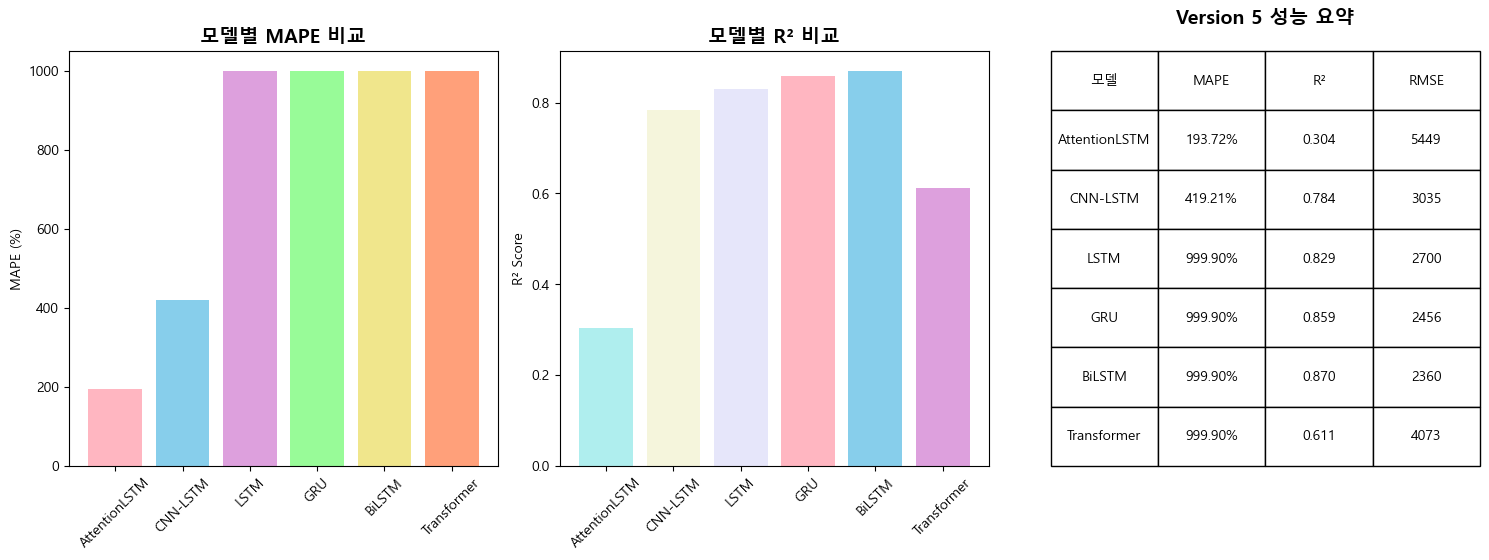

🎨 Version 5 시각화 완료!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime
import os

# 파스텔 색상 정의 (이미 했다면 생략)
pastel_colors = {
    'primary': '#FFB6C1', 'secondary': '#87CEEB', 'accent': '#DDA0DD',
    'success': '#98FB98', 'warning': '#F0E68C', 'danger': '#FFA07A',
    'info': '#AFEEEE', 'light': '#F5F5DC', 'purple': '#E6E6FA'
}

# 저장된 결과 불러오기
result_path = 'C:/ai_x/source/proz/딥러닝 모델 결과'

# 가장 최근 파일 찾기
files = os.listdir(result_path)
performance_files = [f for f in files if f.startswith('딥러닝_모델성능_')]

if performance_files:
    latest_file = sorted(performance_files)[-1]  # 가장 최근 파일
    results_df = pd.read_csv(os.path.join(result_path, latest_file), index_col=0)
    
    # DataFrame을 딕셔너리로 변환
    results = results_df.T.to_dict()
    
    print("✅ 저장된 결과 불러오기 완료!")
    print("📊 모델 성능:")
    for model, metrics in results.items():
        print(f"   {model}: MAPE={metrics['MAPE']:.2f}%, R²={metrics['R²']:.3f}")
    
    # 간단한 시각화
    plt.figure(figsize=(15, 10))
    
    # MAPE 비교
    plt.subplot(2, 3, 1)
    models = list(results.keys())
    mapes = [results[model]['MAPE'] for model in models]
    
    bars = plt.bar(models, mapes, color=[pastel_colors['primary'], pastel_colors['secondary'], 
                                       pastel_colors['accent'], pastel_colors['success'],
                                       pastel_colors['warning'], pastel_colors['danger']][:len(models)])
    plt.title('모델별 MAPE 비교', fontsize=14, fontweight='bold')
    plt.ylabel('MAPE (%)')
    plt.xticks(rotation=45)
    
    # R² 비교
    plt.subplot(2, 3, 2)
    r2_scores = [results[model]['R²'] for model in models]
    bars = plt.bar(models, r2_scores, color=[pastel_colors['info'], pastel_colors['light'], 
                                           pastel_colors['purple'], pastel_colors['primary'],
                                           pastel_colors['secondary'], pastel_colors['accent']][:len(models)])
    plt.title('모델별 R² 비교', fontsize=14, fontweight='bold')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    
    # 성능 요약 테이블
    plt.subplot(2, 3, 3)
    plt.axis('off')
    
    table_data = []
    for model in models:
        table_data.append([
            model,
            f"{results[model]['MAPE']:.2f}%",
            f"{results[model]['R²']:.3f}",
            f"{results[model]['RMSE']:.0f}"
        ])
    
    table = plt.table(cellText=table_data,
                     colLabels=['모델', 'MAPE', 'R²', 'RMSE'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    plt.title('Version 5 성능 요약', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("🎨 Version 5 시각화 완료!")
    
else:
    print("❌ 저장된 성능 파일을 찾을 수 없습니다.")